# ZINC loader statistics

This notebook inspects one selected `ZINCLoader` CSV export and draws graph-level statistics for that dataset. In practice the common workflow is to work with a specific ZINC export such as `zinc_250k`, not to browse a broad dataset catalog.


In [24]:
from pathlib import Path
import runpy

BOOTSTRAP_CANDIDATES = (
    "notebooks/_bootstrap.py",
    "abstractgraph/notebooks/_bootstrap.py",
    "abstractgraph-ml/notebooks/_bootstrap.py",
    "abstractgraph-generative/notebooks/_bootstrap.py",
    "abstractgraph-graphicalizer/notebooks/_bootstrap.py",
)

_bootstrap_path = next(
    (
        candidate / relative
        for candidate in (Path.cwd(), *Path.cwd().parents)
        for relative in BOOTSTRAP_CANDIDATES
        if (candidate / relative).exists()
    ),
    None,
)
if _bootstrap_path is None:
    raise FileNotFoundError("Could not locate ecosystem notebooks/_bootstrap.py")

_bootstrap = runpy.run_path(str(_bootstrap_path))
repo_root = _bootstrap["repo_root"]
workspace_root = _bootstrap["workspace_root"]


In [25]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from abstractgraph_graphicalizer.chem import DEFAULT_ZINC_TARGET_COLUMNS, ZINCLoader, download_zinc_dataset


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Resolve one dataset

This notebook starts from one explicit dataset name. If that CSV is not present locally, it can download the default `zinc_250k.csv` export automatically.


In [26]:
zinc_root = repo_root / "data-local" / "ZINC"
loader = ZINCLoader(zinc_root, on_error="skip")
dataset_name = "zinc_250k"
auto_download_if_missing = True
download_filename = f"{dataset_name}.csv"

try:
    paths = loader.resolve_paths(dataset_name)
except FileNotFoundError:
    loader.root.mkdir(parents=True, exist_ok=True)
    if auto_download_if_missing:
        csv_path = download_zinc_dataset(loader.root, filename=download_filename)
        print(f"Downloaded {csv_path.name} to {csv_path.parent}")
        paths = loader.resolve_paths(dataset_name)
    else:
        raise FileNotFoundError(
            f"Dataset {dataset_name!r} was not found under {loader.root}. "
            "Set auto_download_if_missing=True or place the CSV under that root."
        )

summary = next(
    summary
    for summary in loader.list_datasets()
    if summary.dataset_name == dataset_name
)
dataset_overview = pd.DataFrame(
    [
        {
            "dataset_name": summary.dataset_name,
            "molecule_count": summary.molecule_count,
            "size_mb": summary.size_mb,
            "csv_path": str(summary.csv_path),
        }
    ]
)

print("root:", loader.root)
display(dataset_overview)


root: /home/fabrizio/code/abstractgraph-ecosystem/repos/abstractgraph-graphicalizer/data-local/ZINC


,dataset_name,molecule_count,size_mb,csv_path
0,zinc_250k,249455,21.559323,/home/fabrizio/code/abstractgraph-ecosystem/re...


## Load the selected dataset and inspect graph statistics

The selected CSV is loaded through the cached graph-corpus path owned by `ZINCLoader.load(...)`.


In [27]:
limit = None
max_node_count = None

graphs, metadata = loader.load(
    dataset_name,
    limit=limit,
    max_node_count=max_node_count,
)

print("dataset_name:", dataset_name)
print("csv_path:", paths.csv_path)
print("graphs loaded:", len(graphs))
display(metadata.head())


dataset_name: zinc_250k
csv_path: /home/fabrizio/code/abstractgraph-ecosystem/repos/abstractgraph-graphicalizer/data-local/ZINC/zinc_250k.csv
graphs loaded: 249455


,smiles,logP,qed,SAS,_zinc_row_index
0,C=C(Br)CON\n,0.7853,0.602918,3.834174,44328
1,Br[C@H]1CC[NH2+]C1\n,-0.2830,0.474086,6.467389,70676
2,C/C(I)=C/CI\n,2.7602,0.513224,4.340924,223007
3,Cl/C=C/C(Cl)(Cl)Cl\n,3.1091,0.495470,4.165780,41626
4,O[C@@H](CBr)C1CC1\n,1.1522,0.615928,3.383327,80640


In [28]:
graph_stats = pd.DataFrame(
    {
        "node_count": [graph.number_of_nodes() for graph in graphs],
        "edge_count": [graph.number_of_edges() for graph in graphs],
    }
)
graph_stats["average_degree"] = 2.0 * graph_stats["edge_count"] / graph_stats["node_count"].clip(lower=1)
graph_stats["density"] = 2.0 * graph_stats["edge_count"] / (
    graph_stats["node_count"] * (graph_stats["node_count"] - 1)
).where(graph_stats["node_count"] > 1, 1)

candidate_target_columns = [column for column in DEFAULT_ZINC_TARGET_COLUMNS if column in metadata.columns]
display(graph_stats.head())
graph_stats.describe().transpose()


,node_count,edge_count,average_degree,density
0,6,5,1.666667,0.333333
1,6,6,2.000000,0.400000
2,6,5,1.666667,0.333333
3,7,6,1.714286,0.285714
4,7,7,2.000000,0.333333


,count,mean,std,min,25%,50%,75%,max
node_count,249455.0,23.151362,4.509344,6.000000,20.000000,23.000000,26.000000,38.000000
edge_count,249455.0,24.902223,5.295760,5.000000,21.000000,25.000000,28.000000,45.000000
average_degree,249455.0,2.144018,0.071802,1.666667,2.095238,2.153846,2.190476,2.666667
density,249455.0,0.100956,0.021764,0.060060,0.086154,0.094862,0.110526,0.400000


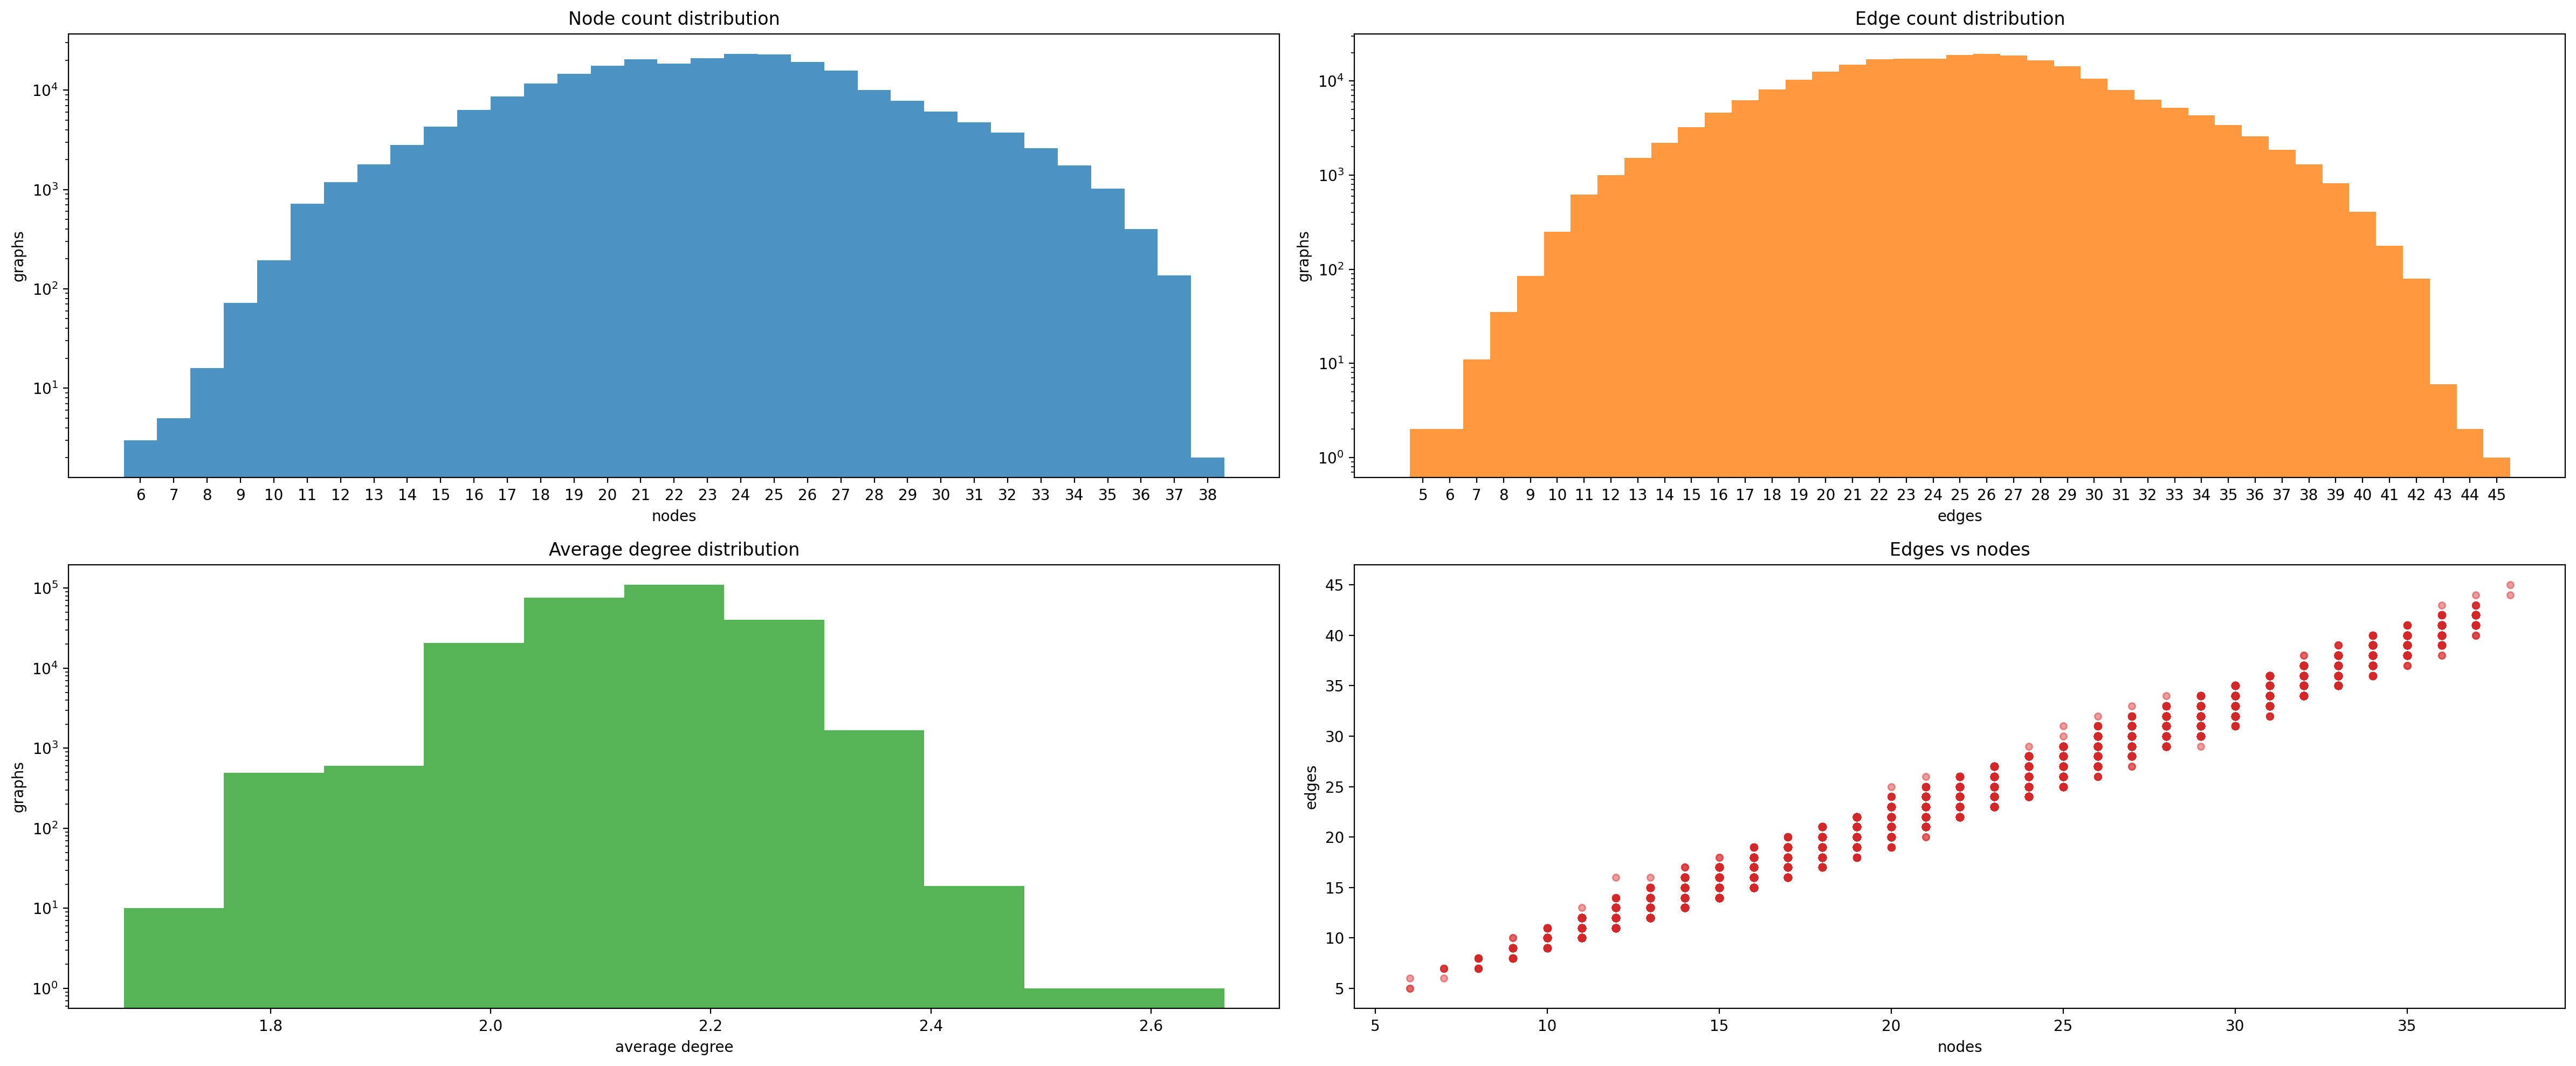

In [29]:
fig, axes = plt.subplots(2, 2, figsize=(24, 10))

node_tick_values = np.arange(graph_stats["node_count"].min(), graph_stats["node_count"].max() + 1, 1)
node_bins = np.arange(graph_stats["node_count"].min() - 0.5, graph_stats["node_count"].max() + 1.5, 1)
edge_tick_values = np.arange(graph_stats["edge_count"].min(), graph_stats["edge_count"].max() + 1, 1)
edge_bins = np.arange(graph_stats["edge_count"].min() - 0.5, graph_stats["edge_count"].max() + 1.5, 1)

axes[0, 0].hist(graph_stats["node_count"], bins=node_bins, color="#1f77b4", alpha=0.8)
axes[0, 0].set_yscale("log")
axes[0, 0].set_xticks(node_tick_values)
axes[0, 0].set_title("Node count distribution")
axes[0, 0].set_xlabel("nodes")
axes[0, 0].set_ylabel("graphs")

axes[0, 1].hist(graph_stats["edge_count"], bins=edge_bins, color="#ff7f0e", alpha=0.8)
axes[0, 1].set_yscale("log")
axes[0, 1].set_xticks(edge_tick_values)
axes[0, 1].set_title("Edge count distribution")
axes[0, 1].set_xlabel("edges")
axes[0, 1].set_ylabel("graphs")

axes[1, 0].hist(graph_stats["average_degree"], bins=11, log=True, color="#2ca02c", alpha=0.8)
axes[1, 0].set_title("Average degree distribution")
axes[1, 0].set_xlabel("average degree")
axes[1, 0].set_ylabel("graphs")

axes[1, 1].scatter(graph_stats["node_count"], graph_stats["edge_count"], s=20, alpha=0.45, color="#d62728")
axes[1, 1].set_title("Edges vs nodes")
axes[1, 1].set_xlabel("nodes")
axes[1, 1].set_ylabel("edges")

plt.tight_layout()


In [30]:
summary = pd.DataFrame(
    {
        "graphs": [len(graph_stats)],
        "mean_nodes": [graph_stats["node_count"].mean()],
        "median_nodes": [graph_stats["node_count"].median()],
        "mean_edges": [graph_stats["edge_count"].mean()],
        "median_edges": [graph_stats["edge_count"].median()],
        "mean_density": [graph_stats["density"].mean()],
    },
    index=[dataset_name],
).round(3)

summary


,graphs,mean_nodes,median_nodes,mean_edges,median_edges,mean_density
zinc_250k,249455,23.151,23.0,24.902,25.0,0.101


## Optional target statistics

Many ZINC CSVs include regression targets such as `logP`, `qed`, or `SAS`. If those columns exist in the selected dataset, the next cell plots them.


,count,mean,std,min,25%,50%,75%,max
logP,249455.0,2.457093,1.434330,-6.876200,1.574810,2.605600,3.486760,8.252100
qed,249455.0,0.728264,0.139565,0.111811,0.645872,0.759878,0.835714,0.947882
SAS,249455.0,3.053235,0.834796,1.132738,2.416627,2.892993,3.545533,7.289283


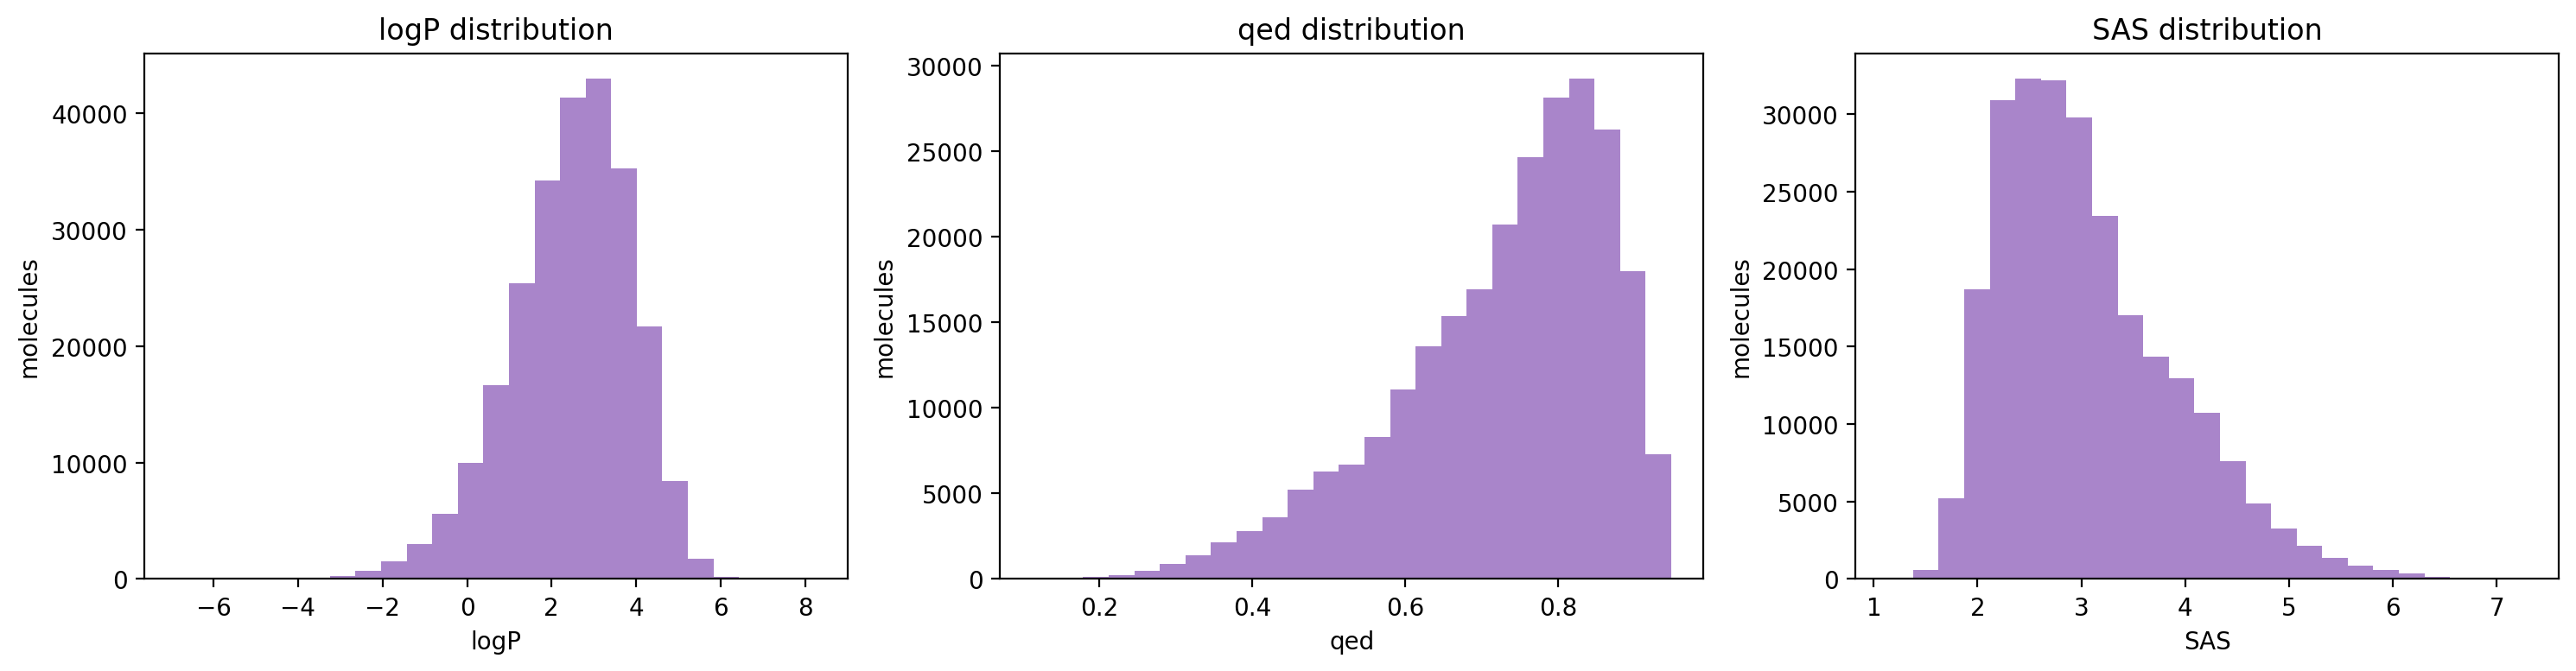

In [31]:
if candidate_target_columns:
    target_frame = metadata.loc[:, candidate_target_columns].copy()
    display(target_frame.describe().transpose())

    fig, axes = plt.subplots(1, len(candidate_target_columns), figsize=(5 * len(candidate_target_columns), 4))
    if len(candidate_target_columns) == 1:
        axes = [axes]

    for axis, column in zip(axes, candidate_target_columns):
        axis.hist(target_frame[column].dropna(), bins=25, color="#9467bd", alpha=0.8)
        axis.set_title(f"{column} distribution")
        axis.set_xlabel(column)
        axis.set_ylabel("molecules")

    plt.tight_layout()
else:
    print("No default ZINC target columns found in this dataset:", DEFAULT_ZINC_TARGET_COLUMNS)
